In [1]:
import Computational_v4_BLB as Computational
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
import numpy as np
import imageio.v2 as imageio
from matplotlib import pyplot as plt
import pandas as pd
import cv2 
from sklearn.decomposition import PCA as sklearnPCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA
from skimage.filters import gaussian
import os
import PySimpleGUI as sg
from PIL import Image
from io import BytesIO
import io
import seaborn as sns
from tqdm import tqdm
from skimage import morphology

# In[2]:

In [3]:
import scipy.linalg as spla
import numpy.linalg as la

In [4]:
def upload(name):
    layout = [[sg.Text('Choose Folders with Files for ' + str(name) + ' patient:')],
              [sg.Text('Folder with skin photos:', size=(22, 1)), sg.InputText(), sg.FolderBrowse()],
              [sg.Submit(), sg.Cancel()]]
    window = sg.Window('Photos upload', layout)
    event, values = window.read()
    window.close()
    
    for current_dir, next_dir, files in os.walk(values[0], topdown=True):
        continue
        
    gray = lambda rgb : np.dot(rgb[... , :3] , [1. , 1., 1. ])    
    images_cube = np.array(list(gray(np.array(imageio.imread(current_dir + '/' + files[i]))).T for i in range(8))).T
#     hypercube_of_images = np.dstack((tuple(images_cube)))
    return images_cube#hypercube_of_images


In [5]:
def crop_image(hypercube_of_images, name):
    w_name = "Contour Determination"
    
    def motion():
        return f'X, Y = {window.user_bind_event.x, window.user_bind_event.y}'
    
    def update_spinners():
        if x1 is None:
            window["click_coordinates_x1"].update(0)
            window["click_coordinates_y1"].update(0)
            window["click_coordinates_x1"].update(disabled=True)
            window["click_coordinates_y1"].update(disabled=True)
        else:
            window["click_coordinates_x1"].update(disabled=False)
            window["click_coordinates_y1"].update(disabled=False)
        if x2 is None:
            window["click_coordinates_x2"].update(0)
            window["click_coordinates_y2"].update(0)
            window["click_coordinates_x2"].update(disabled=True)
            window["click_coordinates_y2"].update(disabled=True)
        else:
            window["click_coordinates_x2"].update(disabled=False)
            window["click_coordinates_y2"].update(disabled=False)
            
            
    def create_rectangles():
        for i in rectangle_numbers:
              window["canvas1"].delete_figure(i)
        rectangle_numbers.append(
            window["canvas1"].draw_rectangle(
                    top_left=(x1, y1),
                    bottom_right=(x2, y2),
                    line_color="red",
                    line_width=2))


    win_size = (750,750)
    pixels_amount = 560
    graph_size = (pixels_amount, int(pixels_amount * 3 / 4))
    col1 = [[sg.Text("mouse now:"), sg.Text("??", key="mouse_now", size=(20,1)), ],
        [sg.Text("last click: "), sg.Text("?,?",key="click_coordinates0"),  sg.Text("click #: 0", key="click_counter")]]
    col2 = [[sg.Text("1: topleft of r1, c1: ", key="c1", background_color="green"),
        sg.Spin(list(range(win_size[0])), key="click_coordinates_x1", enable_events=True),
        sg.Spin(list(range(win_size[1])), key="click_coordinates_y1", enable_events=True),],
        [sg.Text("2: bottomright r1, c1: ", key="c2"),
         sg.Spin(list(range(win_size[0])), key="click_coordinates_x2", enable_events=True),
         sg.Spin(list(range(win_size[1])), key="click_coordinates_y2", enable_events=True),]]
    mouse_column = [sg.Column(col1), sg.Column(col2)]
    
    layout = [[sg.Text("Patient: " + str(name)), 
               sg.Button("Next Channel", bind_return_key=True),
               sg.Button("Previous Channel", bind_return_key=True)],
              [mouse_column,],    
              [sg.Button("Crop with given coordinates"), sg.Button("Choose Whole Picture")],  
              [sg.Graph(canvas_size=graph_size,
                pad=0,
                graph_bottom_left=(0, graph_size[1]),
                graph_top_right=(graph_size[0], 0),
                key = "canvas1",
                enable_events=True,
                #motion_events=True,
                background_color= "#ccffcc",)],
             ]
    


    window = sg.Window(w_name,
                    layout = layout,
                    #size = win_size,
                    return_keyboard_events=True, 
                    grab_anywhere=True)
    
    
    original = None
    filename = None
    x,y = None, None
    x1,y1 = None, None
    x2,y2 = None, None
    Work_Book = {}
    canvas_x, canvas_y = 10, 206 # topleft of canvas 
    rectangle_numbers = []
    click_counter = 0

    window.finalize()

    window.bind('<Motion>', 'motion')
    ##### Showing image in the window 
    slice_of_hypercube = 1
    file = hypercube_of_images[:,:,1]
    uint8_file = np.uint8((file - file.min())/(file - file.min()).max()*255)
    image = Image.fromarray(uint8_file, mode = 'L') 
    image.thumbnail((graph_size[0], graph_size[1]))
    bio = io.BytesIO()
    image.save(bio, format="PNG")
    original = window["canvas1"].draw_image(data=bio.getvalue(), location = (0,0))
    #######
    while True:
        
        event,values = window.read()
        
        if event == sg.WINDOW_CLOSED:
            #window.close()
            #continue 
            break 
        
        

        if event == "canvas_x":
            canvas_x = int(values["canvas_x"])
        if event == "canvas_y":
            canvas_y = int(values["canvas_y"])

        if event == "motion":
            window["mouse_now"].update(motion())

        # get clicks coordinates
        if event == "canvas1":
            #print("clicked at:", values['canvas1'])
            window["click_coordinates0"].update(values['canvas1'])
            x,y = values['canvas1']
            click_counter += 1
            if click_counter > 2:
                click_counter = 0
            if click_counter == 0:
                x1,y1,x2,y2 = None, None, None, None
                update_spinners()
                window["c1"].update(background_color = "green")
                window["c2"].update(background_color = "grey")

                # delete all old rectangles
                for i in rectangle_numbers:
                    window["canvas1"].delete_figure(i)
            elif click_counter == 1:
                x1,y1 = x, y
                x2,y2 = None, None, 
                update_spinners()
                window["c1"].update(background_color = "grey")
                window["c2"].update(background_color = "green")

            elif click_counter == 2:
                x2, y2 = x, y
                update_spinners()
                window["c1"].update(background_color = "grey")
                window["c2"].update(background_color = "grey")
                #create_rectangles()
                for i in rectangle_numbers:
                    window["canvas1"].delete_figure(i)
                rectangle_numbers.append(
                    window["canvas1"].draw_rectangle(
                                top_left=(x1, y1),
                                bottom_right=(x2, y2),
                                line_color="red",
                                line_width=2))

            window["click_counter"].update(f"click #: {click_counter}")
            window["click_coordinates_x1"].update(value= x1)
            window["click_coordinates_y1"].update(value= y1)
            window["click_coordinates_x2"].update(value= x2)
            window["click_coordinates_y2"].update(value= y2)    

        if "click_coordinates_" in event:
            # a spinner was changed
            if x1 is not None:
                x1 = int(window["click_coordinates_x1"].get())
                y1 = int(window["click_coordinates_y1"].get())
            if x2 is not None:
                x2 = int(window["click_coordinates_x2"].get())
                y2 = int(window["click_coordinates_y2"].get())

            #print(x1,x2,x2,y2)
            for i in rectangle_numbers:
                window["canvas1"].delete_figure(i)
            rectangle_numbers.append(
                    window["canvas1"].draw_rectangle(
                                top_left=(x1, y1),
                                bottom_right=(x2, y2),
                                line_color="red",
                                line_width=2))
                #create_rectangles()

        if event == "Next Channel":
            if slice_of_hypercube == hypercube_of_images.shape[2]-1:
                if original is not None:
                    # delete old image first 
                    window["canvas1"].delete_figure(original)
                slice_of_hypercube += 0
                file = hypercube_of_images[:,:,slice_of_hypercube]
                uint8_file = np.uint8((file - file.min())/(file - file.min()).max()*255)
                image = Image.fromarray(uint8_file, mode = 'L') 
                image.thumbnail((graph_size[0], graph_size[1]))
                bio = io.BytesIO()
                image.save(bio, format="PNG")
                original = window["canvas1"].draw_image(data=bio.getvalue(), location = (0,0))
            else:
                if original is not None:
                    # delete old image first 
                    window["canvas1"].delete_figure(original)
                slice_of_hypercube += 1
                file = hypercube_of_images[:,:,slice_of_hypercube]
                uint8_file = np.uint8((file - file.min())/(file - file.min()).max()*255)
                image = Image.fromarray(uint8_file, mode = 'L') 
                image.thumbnail((graph_size[0], graph_size[1]))
                bio = io.BytesIO()
                image.save(bio, format="PNG")
                original = window["canvas1"].draw_image(data=bio.getvalue(), location = (0,0))
                
        if event == "Previous Channel":
            if slice_of_hypercube == 0:
                if original is not None:
                    # delete old image first 
                    window["canvas1"].delete_figure(original)
                slice_of_hypercube += 0
                file = hypercube_of_images[:,:,slice_of_hypercube]
                uint8_file = np.uint8((file - file.min())/(file - file.min()).max()*255)
                image = Image.fromarray(uint8_file, mode = 'L') 
                image.thumbnail((graph_size[0], graph_size[1]))
                bio = io.BytesIO()
                image.save(bio, format="PNG")
                original = window["canvas1"].draw_image(data=bio.getvalue(), location = (0,0))
            else:
                if original is not None:
                    # delete old image first 
                    window["canvas1"].delete_figure(original)
                slice_of_hypercube -= 1
                file = hypercube_of_images[:,:,slice_of_hypercube]
                uint8_file = np.uint8((file - file.min())/(file - file.min()).max()*255)
                image = Image.fromarray(uint8_file, mode = 'L') 
                image.thumbnail((graph_size[0], graph_size[1]))
                bio = io.BytesIO()
                image.save(bio, format="PNG")
                original = window["canvas1"].draw_image(data=bio.getvalue(), location = (0,0))

        if event == "Crop with given coordinates":
            window.close()
            
            Ref_adress = r'C:\Users\admin\Desktop\Skoltech\Project_Personal_medicine\Computational files\New Reference'
            for current_dir, next_dir, reference_files in os.walk(Ref_adress, topdown=True):
                continue

            for b in range(np.array(reference_files).size):
                if reference_files[b][::-1][4] != str(b+1):
                    print('Error in order of files')
                    break
                reference_files[b] = current_dir + '/' + reference_files[b]
                
            
            gray = lambda rgb : np.dot(rgb[... , :3] , [1. , 1., 1. ])
            ref_images_cube = np.array(list(gray(np.array(imageio.imread(reference_files[i]))).T for i in range(8))).T
#             ref_hypercube_of_images = np.dstack((tuple(ref_images_cube)))
        
               
            hc_output = hypercube_of_images[int(y1*1536/420):int(y2*1536/420),int(x1*2048/560):int(x2*2048/560),:]
            hc_output = hc_output / (ref_images_cube[int(y1*1536/420):int(y2*1536/420),int(x1*2048/560):int(x2*2048/560),:]+1e-4)
            return hc_output
        
        
        if event == "Choose Whole Picture":
            window.close()
            
            Ref_adress = r'C:\Users\admin\Desktop\Skoltech\Project_Personal_medicine\Computational files\New Reference'
            for current_dir, next_dir, reference_files in os.walk(Ref_adress, topdown=True):
                continue

            for b in range(np.array(reference_files).size):
                if reference_files[b][::-1][4] != str(b+1):
                    print('Error in order of files')
                    break
                reference_files[b] = current_dir + '/' + reference_files[b]
                
            
            gray = lambda rgb : np.dot(rgb[... , :3] , [1. , 1., 1. ])
            ref_images_cube = np.array(list(gray(np.array(imageio.imread(reference_files[i]))).T for i in range(8))).T
#             ref_hypercube_of_images = np.dstack((tuple(ref_images_cube)))
        
               
            hc_output = hypercube_of_images
            hc_output = hc_output / (ref_images_cube+1e-4)
            return hc_output
        
    window.close()
    return Work_Book

In [11]:
def BLB(names):
    hypercube_of_images = {}
    for i in names:
        hypercube_of_images[i] = crop_image(upload(i), i)
        
#     width = hypercube_of_images[names[0]].shape[0]
#     height = hypercube_of_images[names[0]].shape[1]
#     channels = hypercube_of_images[names[0]].shape[2]
#     image = np.reshape(hypercube_of_images[names[0]], (width*height, channels))
    
    Integral_overlap_matrix = pd.DataFrame([[35413.747686, 48266.475592, 32028.051361, 1288.594416, 100.0],
                    [22543.710184, 19790.442082, 11538.285799, 1317.883702, 100.0],
                    [26312.342124, 29340.161853, 2048.738386, 1243.050297, 100.0],
                    [1513.971083, 9325.287882, 157.872203, 1201.872216, 100.0],
                    [1161.464976, 7318.000622, 162.649841, 1137.740404, 100.0],
                    [2435.635426, 2820.807862, 221.053701, 672.096616, 100.0],
                    [3058.380772, 2578.204305, 242.955611, 563.051536, 100.0],
                    [3880.828582, 3115.201821, 293.456509, 475.588304, 100.0]],
                    index = ['460', '495', '520', '630', '660', '800', '850', '880'],
                    columns = ['Hb02','Hb','Bilirubin','Melanin','Background'])
    
    Integral_overlap_matrix=Integral_overlap_matrix.iloc[:, [0, 1, 3, 4]]
    Q, R = la.qr(Integral_overlap_matrix, mode="complete") 
    R_new = R[:4]
    Q_new = Q.T[:4]
    
    amount_of_choromophores = R_new.shape[0]
    BLB_result = {}
    for i in tqdm(names):
        Skin_hypercube = hypercube_of_images[i].T #gives (8, 2048, 1536)
        Concentration_Matrix=np.zeros([amount_of_choromophores, Skin_hypercube.shape[1], Skin_hypercube.shape[2]])
        
        for first_it in range(Skin_hypercube.shape[1]): 
            for second_it in range(Skin_hypercube.shape[2]): 
                OD_column = - np.log10(Skin_hypercube[:, first_it, second_it]+1e-10) 
                Concentration_Matrix[:, first_it, second_it] = spla.solve_triangular(R_new, Q_new.dot(OD_column), lower=False)
        BLB_result[i] = Concentration_Matrix      
        
    return BLB_result   

In [12]:
def Segmentation_Otsu(skin_hypercube, gaussian_blur):
    
    to_fit_area = np.absolute(skin_hypercube[:,:,0]) + np.absolute(skin_hypercube[:,:,1])
    blured_area = gaussian(to_fit_area, gaussian_blur)
    min_value = blured_area.min()
    max_value = blured_area.max()
    treated_area = np.array((blured_area - min_value)/(max_value - min_value)*255, dtype = np.uint8)  
    ret, th = cv2.threshold(treated_area,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
   
    return th

In [13]:
def analysis_of_distributions(dictionary_of_visits, names, gaussian_blur):
    mean_array = {'hemangioma':{}, 'skin': {}}
    std_array = {'hemangioma':{}, 'skin': {}}
    contour_data_for_stat = {}
    dataframe_for_stat = pd.DataFrame(contour_data_for_stat)
    
    for name in names:
        mask = Segmentation_Otsu(dictionary_of_visits[name].T, gaussian_blur = gaussian_blur)
        to_fit_area = np.absolute(dictionary_of_visits[name].T[:,:,0]) + np.absolute(dictionary_of_visits[name].T[:,:,1])
        
        X = np.ravel(mask * to_fit_area)/255
        values_hemangioma = np.array((np.array([i for i in X if i!=0]) - to_fit_area.min())/(to_fit_area.max() - to_fit_area.min())*255)
        X = np.ravel((255 - mask) * to_fit_area)/255
        values_skin = np.array((np.array([i for i in X if i!=0]) - to_fit_area.min())/(to_fit_area.max() - to_fit_area.min())*255)
        mean_array['skin'][name] = np.mean(values_skin)
        std_array['skin'][name] = np.std(values_skin)
        mean_array['hemangioma'][name] = np.mean(values_hemangioma)
        std_array['hemangioma'][name] = np.std(values_hemangioma)
        
        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.suptitle('patient ' + name)
        ax1.imshow(to_fit_area, vmin = np.quantile(to_fit_area, 0.05), vmax = np.quantile(to_fit_area, 0.95))
        ax1.set_xticks([])
        ax1.set_yticks([])
        ax2.imshow(mask)
        ax2.set_xticks([])
        ax2.set_yticks([])
        plt.show()
        
        
    return mean_array, std_array

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [01:00<00:00, 60.68s/it]


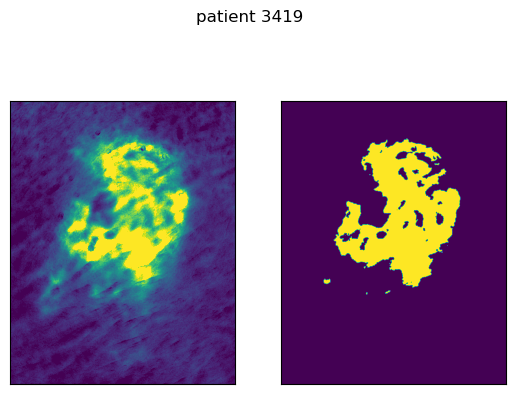

In [14]:
names = ['3419']
BLB_result = BLB(names)      
result_mean, result_std = analysis_of_distributions(BLB_result, names, gaussian_blur = 2)

In [49]:
def Borders_values(dictionary_of_visits, name, gaussian_blur):#, show_pic = False):
    
    to_fit_area = np.absolute(dictionary_of_visits[name].T[:,:,0]) + np.absolute(dictionary_of_visits[name].T[:,:,1])
    blured_area = gaussian(to_fit_area, gaussian_blur)
    min_value = blured_area.min()
    max_value = blured_area.max()
    treated_area = np.array((blured_area - min_value)/(max_value - min_value)*255, dtype = np.uint8)
    
    to_fit_area_true = np.array((blured_area - min_value)/(max_value - min_value)*255)
    
    ret, th = cv2.threshold(treated_area,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    step = 1
    stop = 255
    mean, std, area, length = line_array(treated_area, to_fit_area_true, ret, stop, step)
       
    return mean, std, area, length


In [50]:
def line_array(treated_area, to_fit_area, start, stop, step = 1):
                  
    mean = []
    std = []
    area = []
    length = []
    for i in tqdm(np.arange(start, stop, step)):
        m, s, a, l = contours(treated_area, to_fit_area, i, i+step)
        
        if (np.isnan(m) or np.isnan(s)):
            mean.append(mean[-1])
            std.append(std[-1])
            area.append(area[-1])
            length.append(length[-1])
        else:
            mean.append(m)
            std.append(s)
            area.append(a)
            length.append(l)
            
    return mean, std, area, length

In [51]:
def contours(treated_area, to_fit_area, tr_start, tr_end):
        
    _, binary = cv2.threshold(treated_area, tr_start, 255, cv2.THRESH_BINARY)
    contours, hierarchy = cv2.findContours(np.uint8(255*binary), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    area_ar = [cv2.contourArea(cnt) for cnt in contours]
            
    if area_ar == []:
        contour_area = 0
    else:
        contour_area = sum(area_ar)     
        
    _, binary2 = cv2.threshold(treated_area, tr_end, 255, cv2.THRESH_BINARY)
    
#     if True:
#         contours, hierarchy = cv2.findContours(np.uint8(255*(binary-binary2)), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
#         image2 = cv2.drawContours(np.uint8(treated_area), contours, -1, (255, 0, 255), 5)
#         plt.imshow(image2)
#         plt.show()
#         plt.imshow((binary-binary2)*treated_area)
#         plt.show()
    
#     X = np.ravel((binary2-binary)*treated_area)
#     X = [i for i in X if i!=0]
    
    X = np.ravel((binary2-binary) * to_fit_area)/255
    XX = np.array((np.array([i for i in X if i!=0]) - to_fit_area.min())/(to_fit_area.max() - to_fit_area.min())*255)
        
    return (np.mean(XX), np.std(XX), contour_area, len(XX))

In [61]:
def extract_skin_value(dictionary_of_visits, name, gaussian_blur):#, show_pic = False):
    
    to_fit_area = np.absolute(dictionary_of_visits[name].T[:,:,0]) + np.absolute(dictionary_of_visits[name].T[:,:,1])
    blured_area = gaussian(to_fit_area, gaussian_blur)
    min_value = blured_area.min()
    max_value = blured_area.max()
    treated_area = np.array((blured_area - min_value)/(max_value - min_value)*255, dtype = np.uint8)
    
    to_fit_area_true = np.array((blured_area - min_value)/(max_value - min_value)*255)
    
    ret, th = cv2.threshold(treated_area,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

    new_b = 1 - th
    
    X = np.ravel(new_b * to_fit_area_true)/255
    X = [i for i in X if i!=0]
    return np.mean(X)

In [71]:
mean = {} 
std = {} 
area = {}
length = {}
thresholds = {}
skin = {}
for i in range(len(names)):
    print(i+1)
    mean[i], std[i], area[i], length[i] = Borders_values(BLB_result, names[i], gaussian_blur = 2)
    skin[i] = extract_skin_value(BLB_result, names[i], gaussian_blur = 2)

1


100%|████████████████████████████████████████████████████████████████████████████████| 242/242 [00:29<00:00,  8.15it/s]


In [36]:
print('hemangioma mean')
for i in range(len(names)):
    print(list(result_mean['hemangioma'].values())[i])

hemangioma mean
17.840742124332067


In [37]:
print('hemangioma std')
for i in range(len(names)):
    print(list(result_std['hemangioma'].values())[i])

hemangioma std
12.717520792586669


In [38]:
print('skin mean')
for i in range(len(names)):
    print(list(result_mean['skin'].values())[i])

skin mean
5.3444975862827935


In [39]:
print('skin std')
for i in range(len(names)):
    print(list(result_std['skin'].values())[i])

skin std
1.9009696692193685


In [86]:
print('Mean Slope')
for i in range(len(names)):
    print(-np.ma.masked_invalid(np.diff(mean[i]/skin[i]) / np.diff(np.sqrt(np.array(area[i])/4/np.pi))).mean())

Mean Slope
1.6431330938568744


C:\Users\admin\AppData\Local\Temp\ipykernel_16264\3780917625.py:3: RuntimeWarning: divide by zero encountered in divide
  print(-np.ma.masked_invalid(np.diff(mean[i]/skin[i]) / np.diff(np.sqrt(np.array(area[i])/4/np.pi))).mean())
C:\Users\admin\AppData\Local\Temp\ipykernel_16264\3780917625.py:3: RuntimeWarning: invalid value encountered in divide
  print(-np.ma.masked_invalid(np.diff(mean[i]/skin[i]) / np.diff(np.sqrt(np.array(area[i])/4/np.pi))).mean())


In [74]:
print('Hemangioma Area')
for i in range(len(names)):
    print((area[i])[0])

Hemangioma Area
174779.5
